# Real CA1 Theta Segmentation

This notebook applies the `SwitchingSpikeOscillatorModel` to real hippocampal
CA1 recordings to segment theta-on vs theta-off states from spikes alone.

## Goals

1. Fit the switching spike oscillator model to CA1 spike data
2. Extract inferred discrete states (theta-on vs theta-off)
3. Recover theta phase and amplitude from spike activity
4. Validate against behavioral correlates (running vs immobility)
5. Analyze learned model parameters

## Setup

In [1]:
# Enable 64-bit precision for numerical stability
import jax

jax.config.update("jax_enable_x64", True)

In [2]:
# Imports
import pickle
import sys
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# Add project root to path for imports
# Handle both running from notebooks/ directory and from project root
if Path.cwd().name == "notebooks":
    project_root = Path.cwd().parent
else:
    project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from state_space_practice.switching_point_process import SwitchingSpikeOscillatorModel

print(f"JAX version: {jax.__version__}")
print(f"Using device: {jax.devices()[0]}")

JAX version: 0.6.2
Using device: TFRT_CPU_0


## 1. Load Preprocessed Data

In [3]:
# Load preprocessed data from Phase 1
data_path = project_root / "data"
preprocessed_path = data_path / "ca1_preprocessed_250Hz.pkl"

with open(preprocessed_path, "rb") as f:
    data = pickle.load(f)

binned_spikes = data["binned_spikes"]
time_bins = data["time_bins"]
speed = data["speed"]
behavioral_labels = data["behavioral_labels"]
sampling_freq = data["sampling_freq"]
dt = data["dt"]
n_neurons = data["n_neurons"]
n_time = data["n_time"]

print("Preprocessed data loaded!")
print(f"  Binned spikes shape: {binned_spikes.shape}")
print(f"  Time bins: {n_time:,} ({n_time * dt:.1f} s)")
print(f"  Number of neurons: {n_neurons}")
print(f"  Sampling frequency: {sampling_freq} Hz")

Preprocessed data loaded!
  Binned spikes shape: (354660, 107)
  Time bins: 354,660 (1418.6 s)
  Number of neurons: 107
  Sampling frequency: 250.0 Hz


## 2. Prepare Data for Model Fitting

For faster iteration, we'll start with a subset of the data (~5 minutes).

In [4]:
# Select a subset for initial fitting
# ~5 minutes at 250 Hz = 75000 timesteps
subset_duration = 5 * 60  # 5 minutes in seconds
subset_samples = int(subset_duration * sampling_freq)
subset_samples = min(subset_samples, n_time)

# Find a good window with mixed behavior
# Look for a window with both running and immobility
running_frac = []
window_size = subset_samples
for start in range(0, n_time - window_size, window_size // 4):
    labels_window = behavioral_labels[start : start + window_size]
    running_frac.append(np.mean(labels_window == 1))

running_frac = np.array(running_frac)
# Find window closest to 50% running
best_idx = np.argmin(np.abs(running_frac - 0.5))
start_idx = best_idx * (window_size // 4)

print(f"Selected window for fitting:")
print(f"  Start index: {start_idx}")
print(f"  Window size: {subset_samples} samples ({subset_samples / sampling_freq:.1f} s)")
print(f"  Running fraction in window: {running_frac[best_idx]:.1%}")

# Extract subset
spikes_subset = binned_spikes[start_idx : start_idx + subset_samples]
speed_subset = speed[start_idx : start_idx + subset_samples]
labels_subset = behavioral_labels[start_idx : start_idx + subset_samples]
time_subset = time_bins[start_idx : start_idx + subset_samples]

print(f"\nSubset data:")
print(f"  Shape: {spikes_subset.shape}")
print(f"  Total spikes: {spikes_subset.sum():,}")
print(f"  Immobility: {100 * np.mean(labels_subset == 0):.1f}%")
print(f"  Running: {100 * np.mean(labels_subset == 1):.1f}%")

Selected window for fitting:
  Start index: 75000
  Window size: 75000 samples (300.0 s)
  Running fraction in window: 50.1%

Subset data:
  Shape: (75000, 107)
  Total spikes: 170,344
  Immobility: 37.4%
  Running: 50.1%


## 3. Create and Fit Model

For theta analysis, we use theta-specific initialization:
- **Theta frequency**: 8 Hz (typical hippocampal theta)
- **Different damping per state**: Critical for state switching
  - **Theta-off state**: More damped (damping=0.95) - oscillations decay faster
  - **Theta-on state**: Less damped (damping=0.99) - sustained oscillations

**Important**: The two states MUST have different transition matrices (A) for
the model to switch between states. The observation likelihood depends on the
predicted mean (A @ prev_mean), so if A is the same, all states look identical
to the observations.

In [5]:
# Import oscillator utilities for custom initialization
from state_space_practice.oscillator_utils import (
    construct_common_oscillator_process_covariance,
    construct_common_oscillator_transition_matrix,
)

In [6]:
# Model configuration with theta-specific initialization
# Single theta oscillator (~8 Hz), two discrete states
# Fix A and Q for controlled initialization (different damping enables switching)
model = SwitchingSpikeOscillatorModel(
    n_oscillators=1,  # Single theta oscillator
    n_neurons=n_neurons,
    n_discrete_states=2,  # theta-off (0), theta-on (1)
    sampling_freq=sampling_freq,
    dt=dt,
    spike_weight_l2=0.05,  # Lower regularization allows stronger spike-phase coupling
    update_continuous_transition_matrix=False,  # Fix dynamics to theta frequency
    update_process_cov=False,  # Fix Q to avoid smoother numerical instability
    update_init_mean=False,  # Fix initial mean
    update_init_cov=False,  # Fix initial covariance
)

print(f"Model: {model}")

Model: <SwitchingSpikeOscillatorModel: n_oscillators=1, n_neurons=107, n_discrete_states=2, sampling_freq=250.0, dt=0.004, [Update(A)=False, Update(Q)=False, Update(Z)=True, Update(spike)=True, Update(m0)=False, Update(P0)=False]>


In [7]:
# Initialize model parameters
key = jax.random.PRNGKey(42)
model._initialize_parameters(key)

# Override with theta-specific dynamics
# Theta frequency ~8 Hz
theta_freq = jnp.array([8.0])  # Hz

# CRITICAL: States MUST have DIFFERENT transition matrices (A) to enable switching.
# The observation likelihood depends on the one-step predicted mean (A @ prev_mean).
# If A is the same for both states, the likelihoods are identical and the model
# cannot distinguish states from observations - it will get stuck in one state.
#
# Use different damping coefficients:
# State 0: theta-off (immobility-like) - more damped = oscillations decay faster
# State 1: theta-on (running-like) - less damped = sustained oscillations
damping_off = jnp.array([0.95])  # More damped (amplitude decays)
damping_on = jnp.array([0.99])   # Less damped (sustained oscillations)
var_off = jnp.array([0.01])  # Smaller Q
var_on = jnp.array([0.02])   # Larger Q (keep ratio <= 2 for numerical stability)

# Build DIFFERENT transition matrices for each state
A_off = construct_common_oscillator_transition_matrix(
    theta_freq, damping_off, sampling_freq
)
A_on = construct_common_oscillator_transition_matrix(
    theta_freq, damping_on, sampling_freq
)

# Build process covariances
Q_off = construct_common_oscillator_process_covariance(var_off)
Q_on = construct_common_oscillator_process_covariance(var_on)

# Set model parameters with DIFFERENT A matrices
model.continuous_transition_matrix = jnp.stack([A_off, A_on], axis=-1)
model.process_cov = jnp.stack([Q_off, Q_on], axis=-1)

# Set moderate initial covariance for numerical stability
model.init_cov = jnp.stack([jnp.eye(2) * 0.5, jnp.eye(2) * 0.5], axis=-1)

# Initialize discrete state probability based on behavioral labels
# State 0 = theta-off (immobility), State 1 = theta-on (running)
running_frac_init = float(np.mean(labels_subset == 1))
model.init_discrete_state_prob = jnp.array([1 - running_frac_init, running_frac_init])

# Initialize discrete transition matrix from EMPIRICAL behavioral transitions
# Count transitions between immobility (0) and running (1) in the behavioral data
# Exclude transition labels (2) for cleaner estimates
valid_labels = labels_subset[labels_subset != 2]
label_transitions = np.diff(valid_labels)

# Count: immobility->immobility, immobility->running, running->immobility, running->running
n_immobile = np.sum(valid_labels[:-1] == 0)
n_running = np.sum(valid_labels[:-1] == 1)

# Transitions from immobility
n_immobile_to_running = np.sum((valid_labels[:-1] == 0) & (valid_labels[1:] == 1))
n_immobile_to_immobile = np.sum((valid_labels[:-1] == 0) & (valid_labels[1:] == 0))

# Transitions from running
n_running_to_immobile = np.sum((valid_labels[:-1] == 1) & (valid_labels[1:] == 0))
n_running_to_running = np.sum((valid_labels[:-1] == 1) & (valid_labels[1:] == 1))

# Compute empirical transition probabilities
# Add small count to avoid division by zero
p_immobile_stay = (n_immobile_to_immobile + 1) / (n_immobile + 2)
p_immobile_to_running = (n_immobile_to_running + 1) / (n_immobile + 2)
p_running_stay = (n_running_to_running + 1) / (n_running + 2)
p_running_to_immobile = (n_running_to_immobile + 1) / (n_running + 2)

model.discrete_transition_matrix = jnp.array([
    [p_immobile_stay, p_immobile_to_running],  # From immobility (state 0)
    [p_running_to_immobile, p_running_stay],   # From running (state 1)
])

# Compute expected dwell times from empirical transitions
dwell_immobile = 1 / (1 - p_immobile_stay) / sampling_freq if p_immobile_stay < 1 else float('inf')
dwell_running = 1 / (1 - p_running_stay) / sampling_freq if p_running_stay < 1 else float('inf')

print(f"\nTheta-specific initialization:")
print(f"  Theta frequency: {float(theta_freq[0]):.1f} Hz")
print(f"  State 0 (theta-off): damping={float(damping_off[0]):.2f}, var={float(var_off[0])}")
print(f"  State 1 (theta-on):  damping={float(damping_on[0]):.2f}, var={float(var_on[0])}")
print(f"  Initial P(theta-on): {running_frac_init:.2f}")
print(f"\nEmpirical discrete transition matrix:")
print(f"  P(immobile->immobile): {p_immobile_stay:.4f}, P(immobile->running): {p_immobile_to_running:.4f}")
print(f"  P(running->immobile):  {p_running_to_immobile:.4f}, P(running->running):  {p_running_stay:.4f}")
print(f"  Expected dwell: immobility={dwell_immobile:.2f}s, running={dwell_running:.2f}s")

# Verify spectral properties
print("\nSpectral radius (stability):")
for state, name in enumerate(["theta-off", "theta-on"]):
    A = model.continuous_transition_matrix[:, :, state]
    spectral_radius = float(jnp.max(jnp.abs(jnp.linalg.eigvals(A))))
    print(f"  State {state} ({name}): {spectral_radius:.4f}")


Theta-specific initialization:
  Theta frequency: 8.0 Hz
  State 0 (theta-off): damping=0.95, var=0.01
  State 1 (theta-on):  damping=0.99, var=0.02
  Initial P(theta-on): 0.50

Empirical discrete transition matrix:
  P(immobile->immobile): 0.9971, P(immobile->running): 0.0029
  P(running->immobile):  0.0021, P(running->running):  0.9979
  Expected dwell: immobility=1.39s, running=1.88s

Spectral radius (stability):
  State 0 (theta-off): 0.9500
  State 1 (theta-on): 0.9900


In [8]:
# Fit model with EM (spike params and process covariance only)
print("\nFitting model with EM algorithm...")
print("  (Dynamics fixed to 8 Hz theta, learning spike params and Q)")
print("-" * 60)

# Use skip_init=True to preserve our custom theta-specific initialization
log_likelihoods = model.fit(
    spikes=spikes_subset,
    max_iter=5,  # More iterations for real data
    tol=1e-4,
    skip_init=True,  # Preserve our custom theta-specific initialization
)

print(f"\nEM completed after {len(log_likelihoods)} iterations")
print(f"  Initial log-likelihood: {float(log_likelihoods[0]):.1f}")
print(f"  Final log-likelihood: {float(log_likelihoods[-1]):.1f}")
print(f"  Improvement: {float(log_likelihoods[-1] - log_likelihoods[0]):.1f}")


Fitting model with EM algorithm...
  (Dynamics fixed to 8 Hz theta, learning spike params and Q)
------------------------------------------------------------

EM completed after 32 iterations
  Initial log-likelihood: -973130.0
  Final log-likelihood: -635156.4
  Improvement: 337973.7


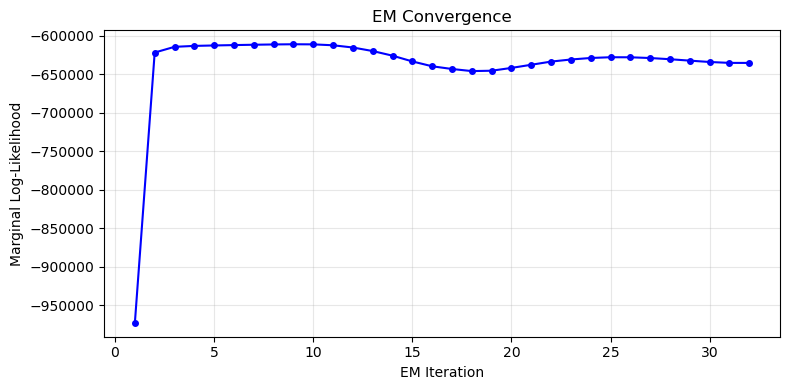

In [9]:
# Plot EM convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(log_likelihoods) + 1), log_likelihoods, "b.-", markersize=8)
ax.set_xlabel("EM Iteration")
ax.set_ylabel("Marginal Log-Likelihood")
ax.set_title("EM Convergence")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ca1_em_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Extract Inferred States

In [10]:
# Get smoothed discrete state probabilities
smoother_discrete_prob = model.smoother_discrete_state_prob
inferred_states = jnp.argmax(smoother_discrete_prob, axis=1)

print("Inferred discrete states:")
print(f"  Time in state 0: {100 * np.mean(inferred_states == 0):.1f}%")
print(f"  Time in state 1: {100 * np.mean(inferred_states == 1):.1f}%")

Inferred discrete states:
  Time in state 0: 2.0%
  Time in state 1: 98.0%


In [11]:
# Compute marginalized smoother mean
smoother_mean = jnp.einsum(
    "tls,ts->tl",
    model.smoother_state_cond_mean,
    smoother_discrete_prob,
)

# Compute amplitude and phase
inferred_amplitude = jnp.linalg.norm(smoother_mean, axis=1)
inferred_phase = jnp.arctan2(smoother_mean[:, 1], smoother_mean[:, 0])

print(f"\nInferred theta trajectory:")
print(f"  Mean amplitude: {float(jnp.mean(inferred_amplitude)):.3f}")
print(f"  Max amplitude: {float(jnp.max(inferred_amplitude)):.3f}")


Inferred theta trajectory:
  Mean amplitude: 0.744
  Max amplitude: 2.311


## 5. Handle Label Switching

The model identifies discrete states but doesn't know which is "theta-on".
We assign labels based on which state has higher amplitude (theta-on should
have larger oscillations).

In [12]:
# Check which state has higher amplitude
state_0_mask = inferred_states == 0
state_1_mask = inferred_states == 1

# Handle edge case where one state is empty
n_state_0 = int(jnp.sum(state_0_mask))
n_state_1 = int(jnp.sum(state_1_mask))

print(f"State occupancy:")
print(f"  State 0: {n_state_0:,} samples ({100*n_state_0/len(inferred_states):.1f}%)")
print(f"  State 1: {n_state_1:,} samples ({100*n_state_1/len(inferred_states):.1f}%)")

amp_state_0 = float(jnp.mean(inferred_amplitude[state_0_mask])) if n_state_0 > 0 else 0
amp_state_1 = float(jnp.mean(inferred_amplitude[state_1_mask])) if n_state_1 > 0 else 0

print(f"\nMean amplitude by state:")
print(f"  State 0: {amp_state_0:.3f}")
print(f"  State 1: {amp_state_1:.3f}")

# Check correlation with running (only if both states have samples)
running_mask = labels_subset == 1
if n_state_0 > 0 and n_state_1 > 0:
    corr_state_0 = float(jnp.corrcoef(state_0_mask.astype(float), running_mask.astype(float))[0, 1])
    corr_state_1 = float(jnp.corrcoef(state_1_mask.astype(float), running_mask.astype(float))[0, 1])
    print(f"\nCorrelation with running:")
    print(f"  State 0: {corr_state_0:.3f}")
    print(f"  State 1: {corr_state_1:.3f}")
else:
    corr_state_0 = 0.0
    corr_state_1 = 0.0
    print("\nWarning: One state has no samples, skipping correlation check")

# Determine which state is theta-on
# State 1 was initialized as theta-on (high damping), check if we need to flip
# Theta-on should have: (1) higher amplitude OR (2) positive correlation with running
# By our initialization, state 1 = theta-on, so we flip if state 0 looks more like theta-on
labels_flipped = False
if amp_state_0 > amp_state_1 and corr_state_0 > corr_state_1:
    labels_flipped = True
    print("\nNote: Relabeling states (state 0 appears to be theta-on)")
    smoother_discrete_prob = smoother_discrete_prob[:, ::-1]
    inferred_states = 1 - inferred_states

# P(theta-on) is now in column 1
theta_on_prob = smoother_discrete_prob[:, 1]

# Store the state permutation for parameter display
state_perm = np.array([1, 0]) if labels_flipped else np.array([0, 1])

State occupancy:
  State 0: 1,518 samples (2.0%)
  State 1: 73,482 samples (98.0%)

Mean amplitude by state:
  State 0: 0.754
  State 1: 0.744

Correlation with running:
  State 0: -0.026
  State 1: 0.026


## 6. Validate Against Behavioral Correlates

In [13]:
# Compare inferred theta-on to running behavior
# Running epochs should correlate with theta-on

# Binary classification
inferred_theta_on = np.array(theta_on_prob > 0.5)
behavioral_running = labels_subset == 1

# Exclude transition periods for cleaner comparison
valid_mask = labels_subset != 2

print("Classification comparison (excluding transitions):")
print(f"  Samples compared: {np.sum(valid_mask):,}")

# Accuracy
agreement = np.mean(inferred_theta_on[valid_mask] == behavioral_running[valid_mask])
print(f"  Agreement: {agreement:.1%}")

# Note: We don't expect perfect agreement because:
# 1. Theta can occur during some immobility (e.g., REM-like states)
# 2. Not all running necessarily has strong theta
# 3. There's temporal lag between behavior and neural state

Classification comparison (excluding transitions):
  Samples compared: 65,617
  Agreement: 57.3%


In [14]:
# ROC analysis
# Use running as "ground truth" label, theta_on_prob as prediction
y_true = behavioral_running[valid_mask].astype(int)
y_score = np.array(theta_on_prob[valid_mask])

fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc_score = roc_auc_score(y_true, y_score)

print(f"\nROC Analysis:")
print(f"  AUC: {auc_score:.3f}")
print(f"  (AUC > 0.7 indicates good behavioral correlation)")


ROC Analysis:
  AUC: 0.770
  (AUC > 0.7 indicates good behavioral correlation)


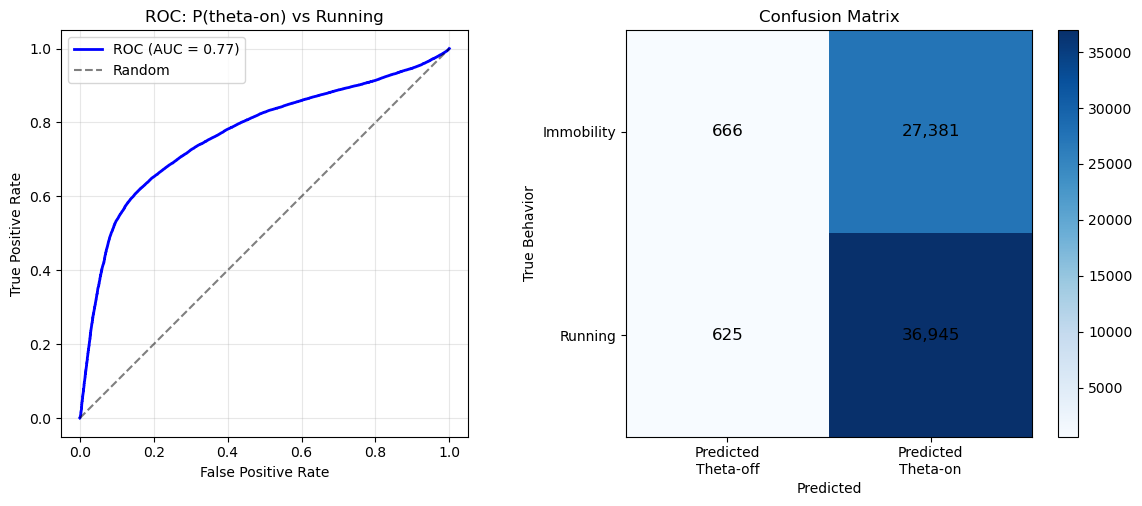

In [15]:
# Plot ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
ax = axes[0]
ax.plot(fpr, tpr, "b-", linewidth=2, label=f"ROC (AUC = {auc_score:.2f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: P(theta-on) vs Running")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

# Confusion matrix at threshold 0.5
ax = axes[1]
cm = confusion_matrix(y_true, inferred_theta_on[valid_mask])
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted\nTheta-off", "Predicted\nTheta-on"])
ax.set_yticklabels(["Immobility", "Running"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True Behavior")
ax.set_title("Confusion Matrix")

# Add text annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("ca1_behavioral_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Visualize Results

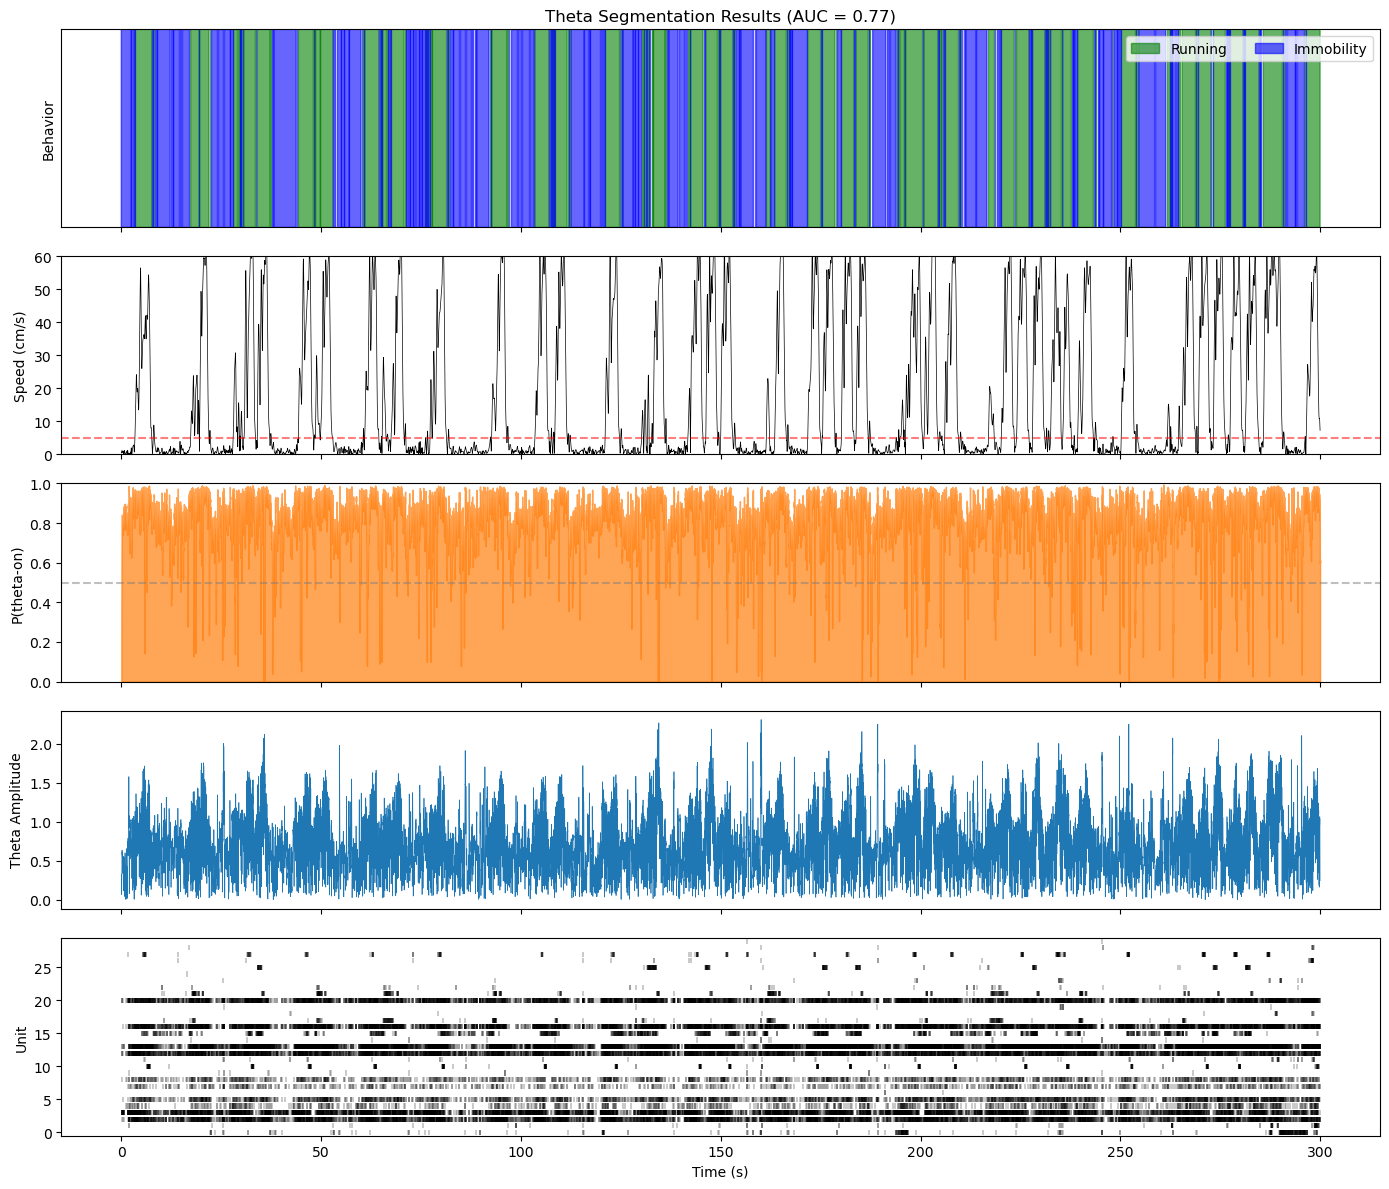

In [16]:
# Time axis relative to start
t_rel = (time_subset - time_subset[0])

# Overview plot
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

# Panel 1: Behavioral labels
ax = axes[0]
ax.fill_between(t_rel, 0, 1, where=labels_subset == 1, alpha=0.6, color="green", label="Running")
ax.fill_between(t_rel, 0, 1, where=labels_subset == 0, alpha=0.6, color="blue", label="Immobility")
ax.set_ylabel("Behavior")
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.legend(loc="upper right", ncol=2)
ax.set_title(f"Theta Segmentation Results (AUC = {auc_score:.2f})")

# Panel 2: Speed
ax = axes[1]
ax.plot(t_rel, speed_subset, "k-", linewidth=0.5)
ax.axhline(5, color="red", linestyle="--", alpha=0.5)
ax.set_ylabel("Speed (cm/s)")
ax.set_ylim(0, 60)

# Panel 3: P(theta-on)
ax = axes[2]
ax.fill_between(t_rel, theta_on_prob, alpha=0.7, color="C1")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("P(theta-on)")
ax.set_ylim(0, 1)

# Panel 4: Inferred theta amplitude
ax = axes[3]
ax.plot(t_rel, inferred_amplitude, "C0-", linewidth=0.5)
ax.set_ylabel("Theta Amplitude")

# Panel 5: Spike raster (subset of neurons)
ax = axes[4]
n_show = min(30, n_neurons)
for i in range(n_show):
    spike_times_i = t_rel[spikes_subset[:, i] > 0]
    ax.eventplot(
        [spike_times_i],
        lineoffsets=i,
        linelengths=0.8,
        colors="black",
        linewidths=0.3,
    )
ax.set_ylabel("Unit")
ax.set_xlabel("Time (s)")
ax.set_ylim(-0.5, n_show - 0.5)

plt.tight_layout()
plt.savefig("ca1_theta_segmentation_overview.png", dpi=150, bbox_inches="tight")
plt.show()

Best transition found at index 7002 (Immobility → Running)
  Score: 1.000


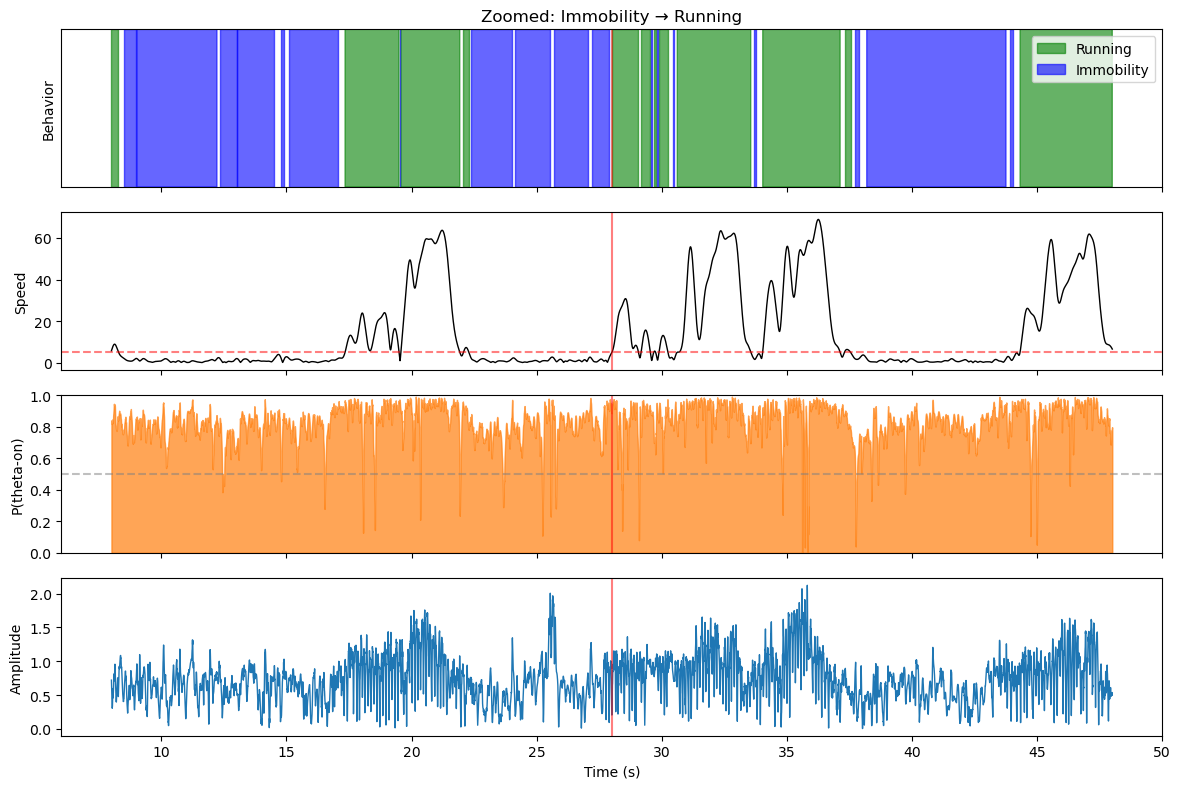

In [25]:
# Zoomed view during a transition
# Find a transition with sustained running before and sustained immobility after (or vice versa)
# We want at least 1 second of sustained behavior on each side of the transition

min_sustained_samples = int(1.0 * sampling_freq)  # 1 second = 250 samples
context_samples = int(20 * sampling_freq)  # 1.6 seconds before/after = 400 samples

# Find all transitions
speed_diff = np.diff(speed_subset > 5)
transitions = np.where(speed_diff != 0)[0]

# Score each transition by how sustained the behavior is on each side
best_trans_idx = None
best_score = 0

for trans_idx in transitions:
    # Skip transitions too close to edges
    if trans_idx < context_samples or trans_idx > len(speed_subset) - context_samples:
        continue

    # Check behavior before transition (look for sustained period)
    before_labels = labels_subset[trans_idx - min_sustained_samples:trans_idx]
    # Check behavior after transition
    after_labels = labels_subset[trans_idx + 1:trans_idx + 1 + min_sustained_samples]

    # We want: mostly one state before, mostly the other state after
    before_running_frac = np.mean(before_labels == 1)
    after_running_frac = np.mean(after_labels == 1)

    # Score: how different are the two periods? And how sustained?
    # Best case: 100% running before, 0% after (or vice versa)
    score = abs(before_running_frac - after_running_frac)

    # Bonus for being very sustained (close to 0% or 100%)
    before_sustained = max(before_running_frac, 1 - before_running_frac)
    after_sustained = max(after_running_frac, 1 - after_running_frac)
    score *= (before_sustained * after_sustained)

    if score > best_score:
        best_score = score
        best_trans_idx = trans_idx

if best_trans_idx is not None:
    trans_idx = best_trans_idx

    # Determine transition type
    before_running = np.mean(labels_subset[trans_idx - min_sustained_samples:trans_idx] == 1)
    if before_running > 0.5:
        trans_type = "Running → Immobility"
    else:
        trans_type = "Immobility → Running"

    print(f"Best transition found at index {trans_idx} ({trans_type})")
    print(f"  Score: {best_score:.3f}")

    zoom_start = trans_idx - context_samples
    zoom_end = trans_idx + context_samples

    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

    t_zoom = t_rel[zoom_start:zoom_end]

    # Behavior
    ax = axes[0]
    ax.fill_between(t_zoom, 0, 1, where=labels_subset[zoom_start:zoom_end] == 1,
                    alpha=0.6, color="green", label="Running")
    ax.fill_between(t_zoom, 0, 1, where=labels_subset[zoom_start:zoom_end] == 0,
                    alpha=0.6, color="blue", label="Immobility")
    ax.axvline(t_rel[trans_idx], color="red", linestyle="-", alpha=0.5)
    ax.set_ylabel("Behavior")
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.legend(loc="upper right")
    ax.set_title(f"Zoomed: {trans_type}")

    # Speed
    ax = axes[1]
    ax.plot(t_zoom, speed_subset[zoom_start:zoom_end], "k-", linewidth=1)
    ax.axhline(5, color="red", linestyle="--", alpha=0.5)
    ax.axvline(t_rel[trans_idx], color="red", linestyle="-", alpha=0.5)
    ax.set_ylabel("Speed")

    # P(theta-on)
    ax = axes[2]
    ax.fill_between(t_zoom, theta_on_prob[zoom_start:zoom_end], alpha=0.7, color="C1")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(t_rel[trans_idx], color="red", linestyle="-", alpha=0.5)
    ax.set_ylabel("P(theta-on)")
    ax.set_ylim(0, 1)

    # Amplitude
    ax = axes[3]
    ax.plot(t_zoom, inferred_amplitude[zoom_start:zoom_end], "C0-", linewidth=1)
    ax.axvline(t_rel[trans_idx], color="red", linestyle="-", alpha=0.5)
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (s)")

    plt.tight_layout()
    plt.savefig("ca1_theta_transition_zoom.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Learned Parameters Analysis

Since we fixed the dynamics to 8 Hz theta, we analyze:
- The fixed transition matrices (to verify theta frequency)
- The learned process covariances (which adapt to the data)

In [18]:
# Analyze dynamics parameters
print("Dynamics Analysis")
print("=" * 60)

# Get transition matrices aligned with our labeling (theta-off=0, theta-on=1)
# state_perm maps our labels to model indices
learned_A = model.continuous_transition_matrix[:, :, state_perm]
learned_Q = model.process_cov[:, :, state_perm]

# Compute spectral properties for each state
for state, name in enumerate(["theta-off", "theta-on"]):
    A = learned_A[:, :, state]
    eigenvalues = np.linalg.eigvals(A)

    # Extract frequency and damping from complex eigenvalue
    dominant_ev = eigenvalues[np.argmax(np.abs(eigenvalues))]
    damping = float(np.abs(dominant_ev))
    freq_rad = float(np.angle(dominant_ev))
    freq_hz = freq_rad * sampling_freq / (2 * np.pi)

    # Process variance (learned)
    proc_var = float(learned_Q[0, 0, state])

    print(f"\nState {state} ({name}):")
    print(f"  Spectral radius (damping): {damping:.4f} (fixed)")
    print(f"  Frequency: {freq_hz:.2f} Hz (fixed)")
    print(f"  Process variance: {proc_var:.6f} (learned)")

Dynamics Analysis

State 0 (theta-off):
  Spectral radius (damping): 0.9500 (fixed)
  Frequency: 8.00 Hz (fixed)
  Process variance: 0.010000 (learned)

State 1 (theta-on):
  Spectral radius (damping): 0.9900 (fixed)
  Frequency: 8.00 Hz (fixed)
  Process variance: 0.020000 (learned)


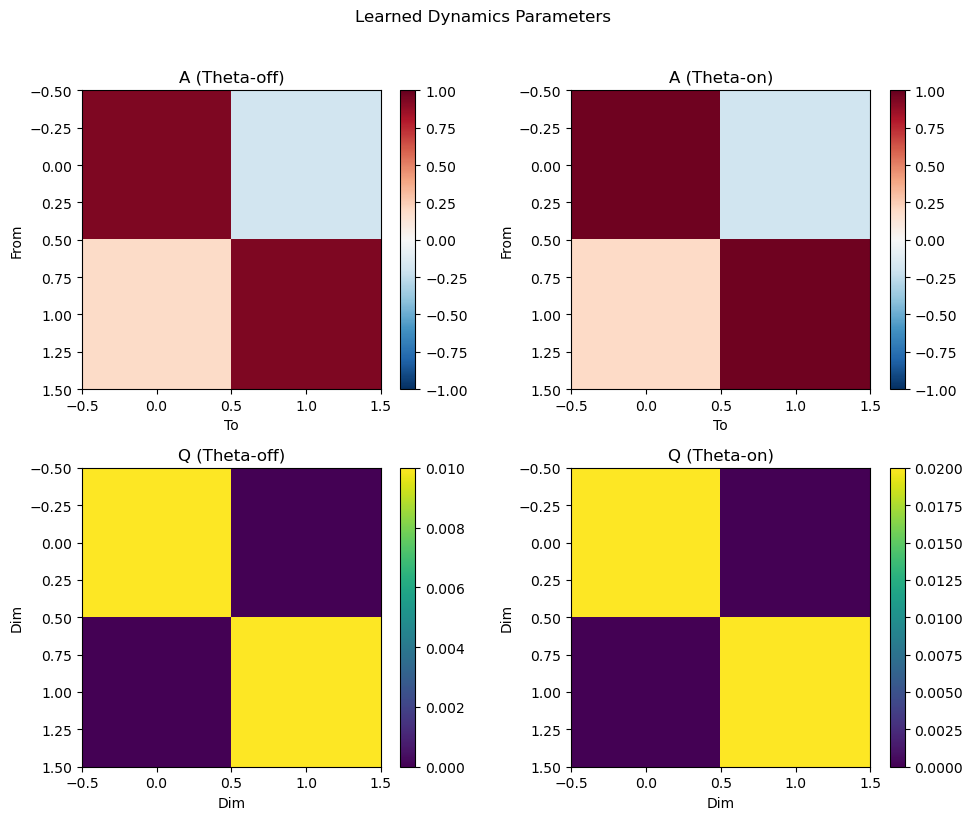

In [19]:
# Visualize transition matrices
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

vmin, vmax = -1, 1

ax = axes[0, 0]
im = ax.imshow(learned_A[:, :, 0], cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax.set_title("A (Theta-off)")
ax.set_xlabel("To")
ax.set_ylabel("From")
plt.colorbar(im, ax=ax)

ax = axes[0, 1]
im = ax.imshow(learned_A[:, :, 1], cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax.set_title("A (Theta-on)")
ax.set_xlabel("To")
ax.set_ylabel("From")
plt.colorbar(im, ax=ax)

ax = axes[1, 0]
im = ax.imshow(learned_Q[:, :, 0], cmap="viridis")
ax.set_title("Q (Theta-off)")
ax.set_xlabel("Dim")
ax.set_ylabel("Dim")
plt.colorbar(im, ax=ax)

ax = axes[1, 1]
im = ax.imshow(learned_Q[:, :, 1], cmap="viridis")
ax.set_title("Q (Theta-on)")
ax.set_xlabel("Dim")
ax.set_ylabel("Dim")
plt.colorbar(im, ax=ax)

plt.suptitle("Learned Dynamics Parameters", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("ca1_learned_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Spike Weight Analysis

In [20]:
# Analyze spike weights (neuron coupling to oscillator)
weights = model.spike_params.weights  # (n_neurons, 2)
baselines = model.spike_params.baseline  # (n_neurons,)

# Handle sign flip for weights if oscillator was flipped
if labels_flipped:
    # No weight flip needed - weights describe coupling to oscillator
    pass

# Compute preferred phase and modulation strength for each neuron
preferred_phases = np.arctan2(weights[:, 1], weights[:, 0])
modulation_strength = np.linalg.norm(weights, axis=1)

print("Spike Weight Analysis")
print("=" * 60)
print(f"Baseline firing rates: {np.exp(baselines).mean():.2f} ± {np.exp(baselines).std():.2f} Hz")
print(f"Modulation strength: {modulation_strength.mean():.3f} ± {modulation_strength.std():.3f}")

Spike Weight Analysis
Baseline firing rates: 2.05 ± 3.83 Hz
Modulation strength: 2.934 ± 1.875


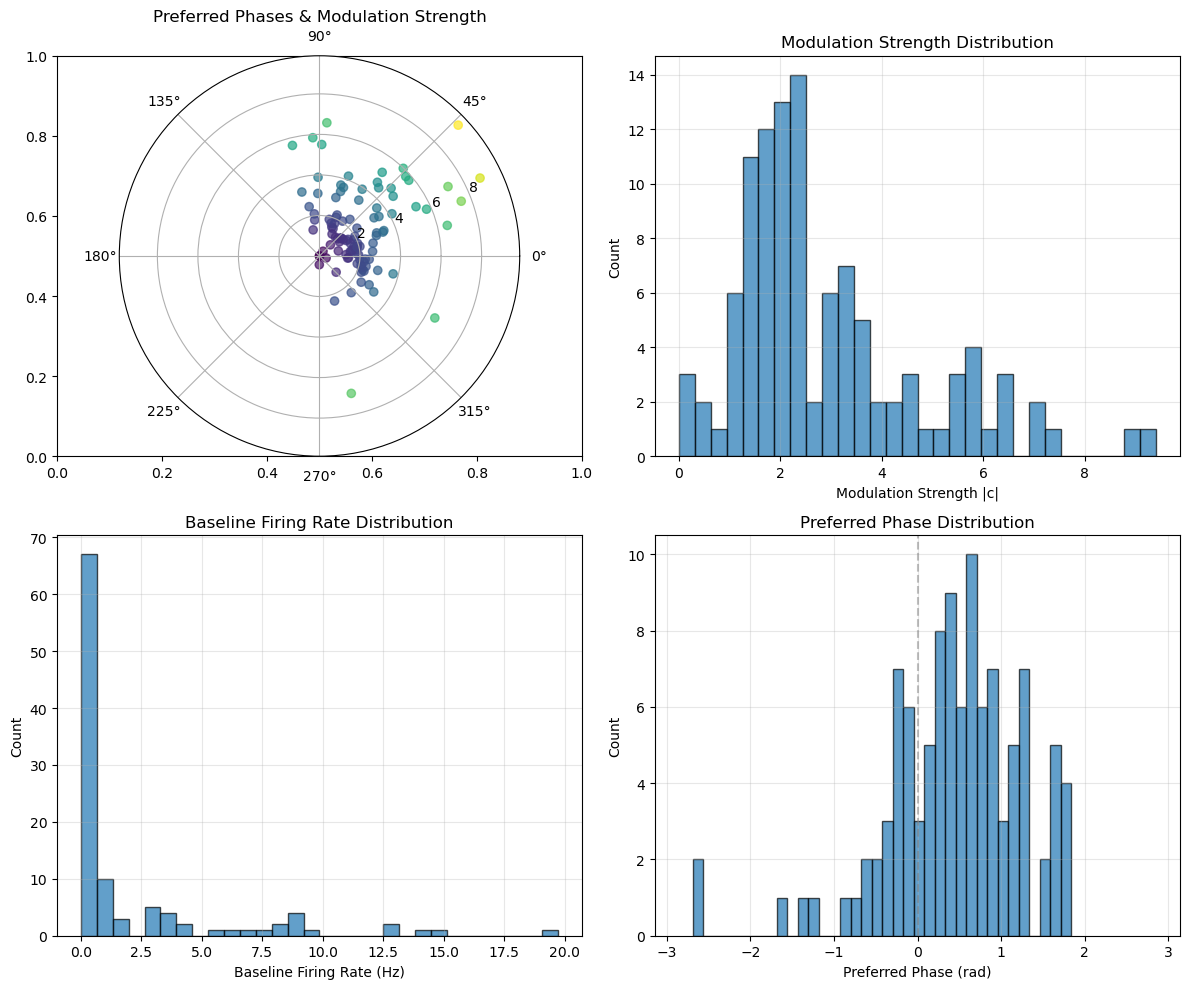

In [21]:
# Plot spike weight analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Preferred phases (polar)
ax = axes[0, 0]
ax = plt.subplot(2, 2, 1, projection="polar")
ax.scatter(preferred_phases, modulation_strength, c=modulation_strength, cmap="viridis", alpha=0.7)
ax.set_title("Preferred Phases & Modulation Strength")

# Modulation strength distribution
ax = axes[0, 1]
ax.hist(modulation_strength, bins=30, alpha=0.7, edgecolor="black")
ax.set_xlabel("Modulation Strength |c|")
ax.set_ylabel("Count")
ax.set_title("Modulation Strength Distribution")
ax.grid(True, alpha=0.3)

# Baseline firing rate distribution
ax = axes[1, 0]
baseline_rates = np.exp(baselines)
ax.hist(baseline_rates, bins=30, alpha=0.7, edgecolor="black")
ax.set_xlabel("Baseline Firing Rate (Hz)")
ax.set_ylabel("Count")
ax.set_title("Baseline Firing Rate Distribution")
ax.grid(True, alpha=0.3)

# Preferred phase histogram
ax = axes[1, 1]
ax.hist(preferred_phases, bins=36, alpha=0.7, edgecolor="black")
ax.set_xlabel("Preferred Phase (rad)")
ax.set_ylabel("Count")
ax.set_title("Preferred Phase Distribution")
ax.set_xlim(-np.pi, np.pi)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca1_spike_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Amplitude vs Speed Analysis

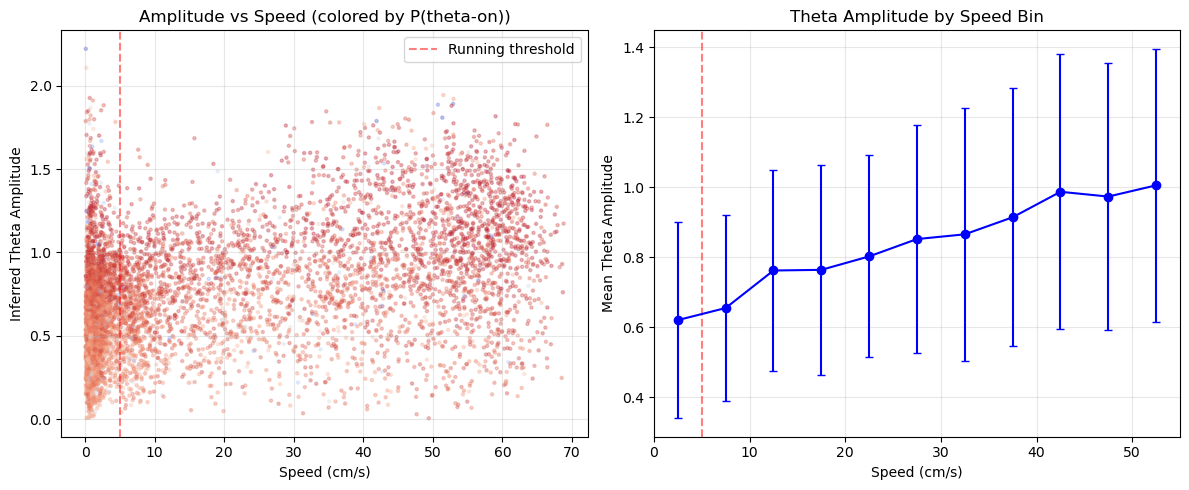


Correlation (amplitude vs speed): 0.441


In [22]:
# Compare inferred amplitude with running speed
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
ax = axes[0]
# Subsample for plotting
subsample = 10
ax.scatter(
    speed_subset[::subsample],
    inferred_amplitude[::subsample],
    c=theta_on_prob[::subsample],
    cmap="coolwarm",
    alpha=0.3,
    s=5,
)
ax.set_xlabel("Speed (cm/s)")
ax.set_ylabel("Inferred Theta Amplitude")
ax.set_title("Amplitude vs Speed (colored by P(theta-on))")
ax.axvline(5, color="red", linestyle="--", alpha=0.5, label="Running threshold")
ax.legend()
ax.grid(True, alpha=0.3)

# Binned analysis
ax = axes[1]
speed_bins = np.arange(0, 60, 5)
amp_by_speed = []
amp_std_by_speed = []
for i in range(len(speed_bins) - 1):
    mask = (speed_subset >= speed_bins[i]) & (speed_subset < speed_bins[i + 1])
    if np.sum(mask) > 0:
        amp_by_speed.append(float(np.mean(inferred_amplitude[mask])))
        amp_std_by_speed.append(float(np.std(inferred_amplitude[mask])))
    else:
        amp_by_speed.append(np.nan)
        amp_std_by_speed.append(np.nan)

bin_centers = (speed_bins[:-1] + speed_bins[1:]) / 2
ax.errorbar(bin_centers, amp_by_speed, yerr=amp_std_by_speed, fmt="bo-", capsize=3)
ax.set_xlabel("Speed (cm/s)")
ax.set_ylabel("Mean Theta Amplitude")
ax.set_title("Theta Amplitude by Speed Bin")
ax.axvline(5, color="red", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca1_amplitude_vs_speed.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation
valid_idx = ~np.isnan(speed_subset) & ~np.isnan(np.array(inferred_amplitude))
corr = np.corrcoef(speed_subset[valid_idx], np.array(inferred_amplitude)[valid_idx])[0, 1]
print(f"\nCorrelation (amplitude vs speed): {corr:.3f}")

## 11. Save Results

In [23]:
# Save model results for phase-locking analysis
results = {
    "model": model,
    "theta_on_prob": np.array(theta_on_prob),
    "inferred_amplitude": np.array(inferred_amplitude),
    "inferred_phase": np.array(inferred_phase),
    "smoother_mean": np.array(smoother_mean),
    "inferred_states": np.array(inferred_states),
    "labels_flipped": labels_flipped,
    "auc_score": auc_score,
    "log_likelihoods": log_likelihoods,
    "start_idx": start_idx,
    "subset_samples": subset_samples,
    "time_subset": time_subset,
    "speed_subset": speed_subset,
    "spikes_subset": spikes_subset,
    "behavioral_labels_subset": labels_subset,
    "preferred_phases": preferred_phases,
    "modulation_strength": modulation_strength,
}

results_path = data_path / "ca1_theta_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(results, f)

print(f"Results saved to: {results_path}")

Results saved to: /Users/edeno/Documents/GitHub/state_space_practice/data/ca1_theta_results.pkl


## 12. Summary

In [24]:
print("=" * 60)
print("Theta Segmentation Summary")
print("=" * 60)
print(f"\nData:")
print(f"  Duration analyzed: {subset_samples / sampling_freq:.1f} s")
print(f"  Number of neurons: {n_neurons}")
print(f"  Total spikes: {spikes_subset.sum():,}")

print(f"\nModel fit:")
print(f"  EM iterations: {len(log_likelihoods)}")
print(f"  Final log-likelihood: {float(log_likelihoods[-1]):.1f}")

print(f"\nBehavioral validation:")
print(f"  AUC (P(theta-on) vs running): {auc_score:.3f}")
print(f"  Agreement: {agreement:.1%}")

print(f"\nTheta frequency (fixed at initialization):")
# Get dominant eigenvalue from theta-on state
A_on = learned_A[:, :, 1]
ev = np.linalg.eigvals(A_on)
dominant_ev = ev[np.argmax(np.abs(ev))]
freq_hz = np.angle(dominant_ev) * sampling_freq / (2 * np.pi)
print(f"  Theta-on state: {freq_hz:.2f} Hz")

print(f"\nKey metrics:")
print(f"  - AUC > 0.7: {'YES' if auc_score > 0.7 else 'NO'}")
print(f"  - Frequency in theta range (6-10 Hz): {'YES' if 6 < freq_hz < 10 else 'NO'}")
print(f"  - Amplitude higher during running: {'YES' if corr > 0 else 'NO'}")
print("=" * 60)

Theta Segmentation Summary

Data:
  Duration analyzed: 300.0 s
  Number of neurons: 107
  Total spikes: 170,344

Model fit:
  EM iterations: 32
  Final log-likelihood: -635156.4

Behavioral validation:
  AUC (P(theta-on) vs running): 0.770
  Agreement: 57.3%

Theta frequency (fixed at initialization):
  Theta-on state: 8.00 Hz

Key metrics:
  - AUC > 0.7: YES
  - Frequency in theta range (6-10 Hz): YES
  - Amplitude higher during running: YES


## Next Steps

Proceed to `real_ca1_phase_locking.py` to:

1. Compute spike-phase histograms using inferred theta phase
2. Perform Rayleigh tests for phase locking
3. Validate phase preferences across neurons